# 01 · Exploración de datos y calidad

**Objetivo:** entender los datos antes de modelar. En este notebook:

1. Cargamos las 8 tablas del dataset sintético.
2. Ejecutamos las validaciones de calidad de datos (DQ).
3. Hacemos un análisis exploratorio (EDA) para descubrir patrones que el modelo deberá capturar.

> Regla de oro: *"Garbage in, garbage out"*. Ningún modelo compensa datos malos, así que la calidad se valida primero.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Permite importar el paquete del proyecto (src/healthsupply) desde el notebook.
sys.path.insert(0, str(Path.cwd().parent / "src"))
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

from healthsupply.data_loading import cargar_todo
from healthsupply.config import DATA_PROCESSED
from healthsupply import figures  # aplica el estilo de gráficos del proyecto

## 1. Carga de datos

El dataset sigue un esquema de **dimensiones** (catálogos: fecha, producto, proveedor, ubicación) y **hechos** (eventos medibles: demanda, inventario, compras, lotes).

In [2]:
t = cargar_todo()
pd.DataFrame({"filas": {k: len(v) for k, v in t.items()},
              "columnas": {k: v.shape[1] for k, v in t.items()}})

,filas,columnas
dim_fecha,1096,10
dim_producto,15,8
dim_proveedor,5,3
dim_ubicacion,5,4
fact_demanda,82200,4
fact_inventario,82200,9
fact_compras,3000,8
fact_lotes,225,7


In [3]:
t["dim_producto"]

,producto_id,producto_nombre,categoria,unidad_medida,costo_unitario,lead_time_dias,vida_util_dias,proveedor_id
0,MED-001,Guantes de nitrilo talla M,Protección,Caja x 100,450,12,1095,PROV-001
1,MED-002,Guantes de nitrilo talla L,Protección,Caja x 100,470,12,1095,PROV-001
2,MED-003,Jeringa 5 ml,Dispositivos,Unidad,380,15,1825,PROV-002
3,MED-004,Jeringa 10 ml,Dispositivos,Unidad,520,15,1825,PROV-002
4,MED-005,Catéter intravenoso 20G,Dispositivos,Unidad,2800,20,1460,PROV-003
5,MED-006,Catéter intravenoso 22G,Dispositivos,Unidad,2900,20,1460,PROV-003
6,MED-007,Gasas estériles 10x10,Curación,Paquete x 10,650,10,1095,PROV-004
7,MED-008,Apósito transparente,Curación,Unidad,1850,14,1095,PROV-004
8,MED-009,Mascarilla quirúrgica,Protección,Caja x 50,1200,10,1095,PROV-001
9,MED-010,Tubo de extracción EDTA,Laboratorio,Unidad,950,18,730,PROV-005


In [4]:
t["fact_inventario"].head()

,fecha,producto_id,ubicacion_id,inventario_inicial,entradas,salidas,inventario_final,inventario_reservado,inventario_disponible
0,2023-01-01,MED-001,LOC-001,933,0,44,889,73,816
1,2023-01-01,MED-001,LOC-002,818,0,31,787,61,726
2,2023-01-01,MED-001,LOC-003,730,0,26,704,70,634
3,2023-01-01,MED-001,LOC-004,834,0,22,812,84,728
4,2023-01-01,MED-001,LOC-005,505,0,21,484,37,447


**Lectura de `fact_inventario`:** cada fila es un día x producto x sede.
`inventario_final = inventario_inicial + entradas - salidas` y `inventario_disponible = inventario_final - inventario_reservado` (lo reservado ya está comprometido y no se puede despachar).

## 2. Validaciones de calidad de datos

Las reglas están en `src/healthsupply/data_quality.py` (y su equivalente en `sql/05_validaciones_calidad.sql`). Se agrupan en completitud, unicidad, validez, consistencia e integridad referencial.

In [5]:
from healthsupply import data_quality as dq

reporte = dq.ejecutar_validaciones(t)
print(dq.resumen(reporte))
reporte.groupby(["dimension", "estado"]).size().unstack(fill_value=0)

46 reglas evaluadas -> OK: 44, ADVERTENCIA: 2, ERROR: 0


estado,ADVERTENCIA,OK
dimension,,
Completitud,0,11
Consistencia,2,9
Integridad referencial,0,10
Unicidad,0,7
Validez,0,7


In [6]:
reporte[reporte["estado"] != "OK"][["tabla", "regla", "registros_fallidos", "descripcion"]]

,tabla,regla,registros_fallidos,descripcion
25,fact_inventario,balance_inicial_entradas_salidas_final,46,"Si falla, las salidas registradas superan el s..."
35,fact_lotes,lotes_vencidos_con_existencias,71,Lotes ya vencidos a la fecha de corte que sigu...


Hay **0 errores** y **2 advertencias**. Las advertencias no son datos corruptos sino **hallazgos de negocio**:

- **Balance que no cuadra (46 filas):** son días en que la demanda superó el stock. Las salidas registradas igualan la demanda, pero el inventario no puede ser negativo y queda en 0. La diferencia es **demanda insatisfecha** (quiebre de stock). Veámoslo:

In [7]:
inv = t["fact_inventario"]
quiebres = inv[inv["inventario_inicial"] + inv["entradas"] - inv["salidas"] != inv["inventario_final"]].copy()
quiebres["demanda_insatisfecha"] = quiebres["salidas"] - (quiebres["inventario_inicial"] + quiebres["entradas"])
print("Años con quiebres:", quiebres["fecha"].dt.year.unique())
quiebres.head(6)

Años con quiebres: [2023]


,fecha,producto_id,ubicacion_id,inventario_inicial,entradas,salidas,inventario_final,inventario_reservado,inventario_disponible,demanda_insatisfecha
915,2023-01-13,MED-004,LOC-001,19,0,39,0,0,0,20
922,2023-01-13,MED-005,LOC-003,7,0,8,0,0,0,1
990,2023-01-14,MED-004,LOC-001,0,0,27,0,0,0,27
997,2023-01-14,MED-005,LOC-003,0,0,6,0,0,0,6
1072,2023-01-15,MED-005,LOC-003,0,0,5,0,0,0,5
1145,2023-01-16,MED-005,LOC-001,11,0,16,0,0,0,5


- **Lotes vencidos con existencias (71 de 225):** lotes cuya fecha de vencimiento ya pasó y todavía tienen unidades. Es dinero perdido y un riesgo sanitario: se deben retirar. Lo cuantificamos en el notebook 03.

## 3. Análisis exploratorio (EDA)

### 3.1 Tendencia y estacionalidad anual

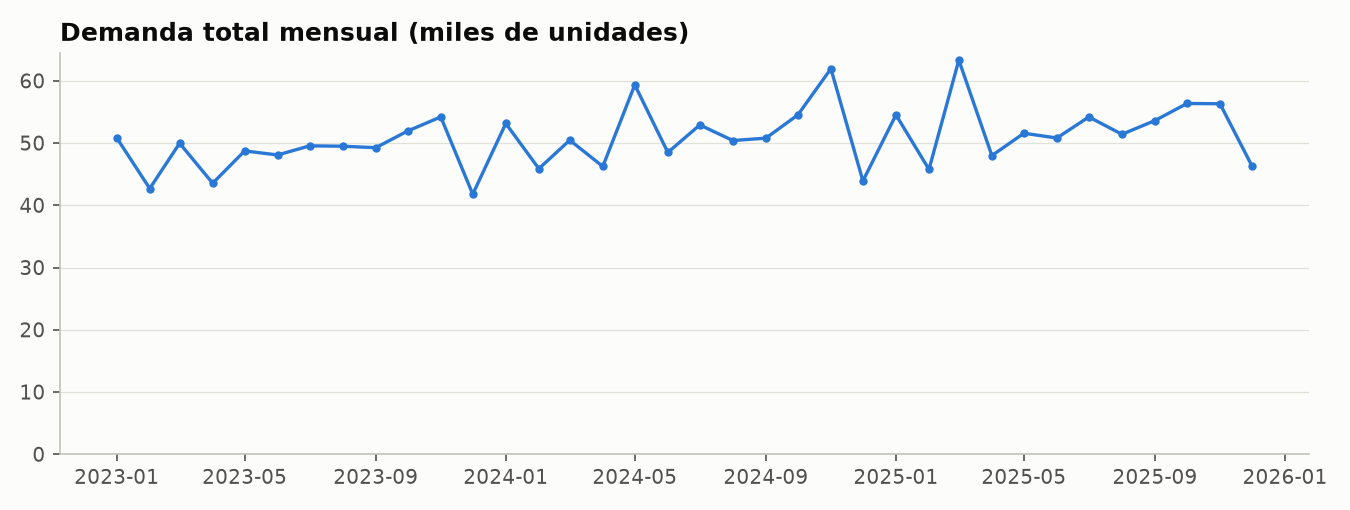

In [8]:
figures.demanda_mensual(t["fact_demanda"])
from IPython.display import Image
Image(figures.FIGURES / "01_demanda_mensual.png")

Observaciones:
- **Tendencia creciente** leve año a año (~+6 % 2024 vs 2023, ~+2 % 2025 vs 2024).
- **Picos en marzo y noviembre** (más marcados en 2024-2025) y **caída en diciembre** todos los años.
- Febrero es bajo en parte porque tiene menos días: por eso modelamos a nivel **diario**.

In [9]:
dem = t["fact_demanda"]
anual = dem.groupby(dem["fecha"].dt.year)["unidades_demandadas"].sum()
pd.DataFrame({"demanda": anual, "crecimiento_%": (anual.pct_change() * 100).round(1)})

,demanda,crecimiento_%
fecha,,
2023,580098,NaN
2024,618080,6.5
2025,632217,2.3


### 3.2 Estacionalidad semanal

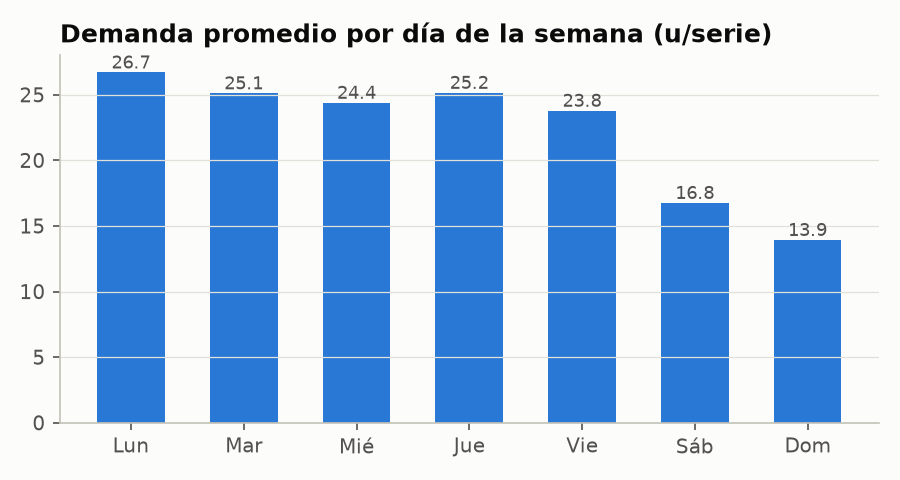

In [10]:
figures.patron_semanal(dem)
Image(figures.FIGURES / "02_patron_semanal.png")

El lunes se demanda ~20 % más que el promedio y el domingo ~37 % menos. **Un pronóstico plano (promedio simple) fallaría todos los días**: sobreestima fines de semana y subestima lunes. Por eso los modelos base incluyen versiones por día de la semana y el modelo de ML recibe `dia_semana` y rezagos de 7 en 7 días.

### 3.3 Volumen por producto y sede

In [11]:
tabla = dem.pivot_table(index="producto_id", columns="ubicacion_id", values="unidades_demandadas", aggfunc="mean").round(1)
tabla.assign(total=tabla.sum(axis=1)).sort_values("total", ascending=False)

ubicacion_id,LOC-001,LOC-002,LOC-003,LOC-004,LOC-005,total
producto_id,,,,,,
MED-001,66.8,50.7,39.5,30.3,34.6,221.9
MED-009,59.4,45.3,34.7,26.7,30.8,196.9
MED-002,56.5,43.0,33.2,25.2,29.3,187.2
MED-007,47.7,36.0,28.1,21.2,24.5,157.5
MED-003,44.6,33.9,26.1,20.0,23.2,147.8
MED-004,35.4,27.2,20.9,16.0,18.5,118.0
MED-010,32.9,24.7,19.2,14.6,16.9,108.3
MED-011,30.0,22.6,17.4,13.3,15.4,98.7
MED-012,26.8,20.1,15.7,12.1,13.8,88.5


Las sedes mantienen una proporción estable (LOC-001 Hospital Central es la más grande). Esto justifica un **modelo global** (uno solo para las 75 series) que aprende el nivel de cada serie a partir de sus rezagos.

### 3.4 ¿Cómo ha evolucionado el inventario? (la historia detrás de los datos)

In [12]:
from healthsupply.kpis import kpis_mensuales

k = kpis_mensuales(inv, t["dim_producto"])
k.groupby(k["mes"].dt.year).agg(
    dias_quiebre=("dias_quiebre", "sum"),
    unidades_no_atendidas=("demanda_insatisfecha", "sum"),
    dias_inventario_prom=("dias_inventario", "mean"),
    fill_rate_prom=("fill_rate", "mean")).round(3)

,dias_quiebre,unidades_no_atendidas,dias_inventario_prom,fill_rate_prom
mes,,,,
2023,46,456,42.309,0.999
2024,0,0,85.021,1.000
2025,0,0,129.218,1.000


In [13]:
doh = k.groupby("mes").apply(lambda g: g["inventario_promedio"].sum() / g["demanda_diaria_prom"].sum())
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(doh.index, doh.values, color=figures.AZUL)
ax.set_title("Días de inventario (cobertura) promedio por mes")
ax.set_ylim(0, None); ax.grid(axis="x", visible=False)
plt.show()

**Hallazgo principal del EDA:** en 2023 hubo **46 días de quiebre** con una cobertura de ~42 días. Aparentemente la respuesta fue comprar más: la cobertura subió a ~85 días en 2024 y ~129 días en 2025, eliminando los quiebres pero generando **sobrestock** y **lotes vencidos**.

Este es el problema clásico que el proyecto resuelve: sin un pronóstico y una política cuantitativa, se oscila entre quedarse sin insumos y acumular capital inmovilizado.

### 3.5 Lead time real de los proveedores

In [14]:
com = t["fact_compras"].merge(t["dim_producto"][["producto_id", "lead_time_dias"]], on="producto_id")
com["lead_time_real"] = (com["fecha_recepcion"] - com["fecha_pedido"]).dt.days
com.groupby("producto_id").agg(planeado=("lead_time_dias", "first"), real_prom=("lead_time_real", "mean"),
                               real_desv=("lead_time_real", "std"), real_max=("lead_time_real", "max")).round(2)

,planeado,real_prom,real_desv,real_max
producto_id,,,,
MED-001,12,11.85,1.50,16
MED-002,12,12.14,1.39,16
MED-003,15,14.90,1.82,19
MED-004,15,15.02,1.99,21
MED-005,20,19.76,2.32,27
MED-006,20,20.08,2.35,26
MED-007,10,10.01,1.25,14
MED-008,14,14.06,1.61,20
MED-009,10,9.98,1.24,13


En promedio los proveedores cumplen el lead time planeado, pero con **variabilidad** (desviación de 1.2 a 2.4 días). Esa variabilidad es una fuente de riesgo que el **stock de seguridad** debe cubrir (notebook 03).

## Conclusiones
- Los datos son **consistentes** (0 errores en 46 reglas). Las 2 advertencias son hallazgos de negocio: quiebres en 2023 y lotes vencidos.
- La demanda tiene **tendencia**, **estacionalidad semanal fuerte** y **estacionalidad anual** (picos en mar/nov, valle en dic).
- El inventario pasó de **quiebres a sobrestock**: motivación directa para el pronóstico y la política de inventario.

➡️ Siguiente: `02_pronostico_demanda.ipynb`